In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
data = pd.read_csv('insurance.csv')

In [ ]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
data['sex'] = data['sex'].replace('female', 'femenino')
data['sex'] = data['sex'].replace('male', 'masculino')
data['smoker'] = data['smoker'].replace('yes', 'si')
data['region'] = data['region'].replace('southwest', 'suroeste')
data['region'] = data['region'].replace('southeast', 'sureste')
data['region'] = data['region'].replace('northwest', 'noroeste')
data['region'] = data['region'].replace('northeast', 'noreste')

In [ ]:
data['sex']
data.rename(columns = {'age': 'edad', 'sex': 'sexo', 'bmi': 'imc', 'children': 'hijos', 'smoker': 'fumador',
                      'charges': 'cargos'}, inplace = True)


# Introducción
Vamos a estar utilizando un dataset sobre los cargos que reciben personas de USA en su seguro de salud. Las variables son las siguientes:
- edad
- sexo
- cantidad de hijos.
- fumadores: si son fumadores actualmente.
- region: region en la que viven del país.
- cargos: cargos recibidos.

In [ ]:
data.head()

,edad,sexo,imc,hijos,fumador,region,cargos
0,19,femenino,27.900,0,si,suroeste,16884.92400
1,18,masculino,33.770,1,no,sureste,1725.55230
2,28,masculino,33.000,3,no,sureste,4449.46200
3,33,masculino,22.705,0,no,noroeste,21984.47061
4,32,masculino,28.880,0,no,noroeste,3866.85520


# Regresión Lineal Simple
Vamos a estudiar cómo varian los cargos con respecto al índice de masa corporal

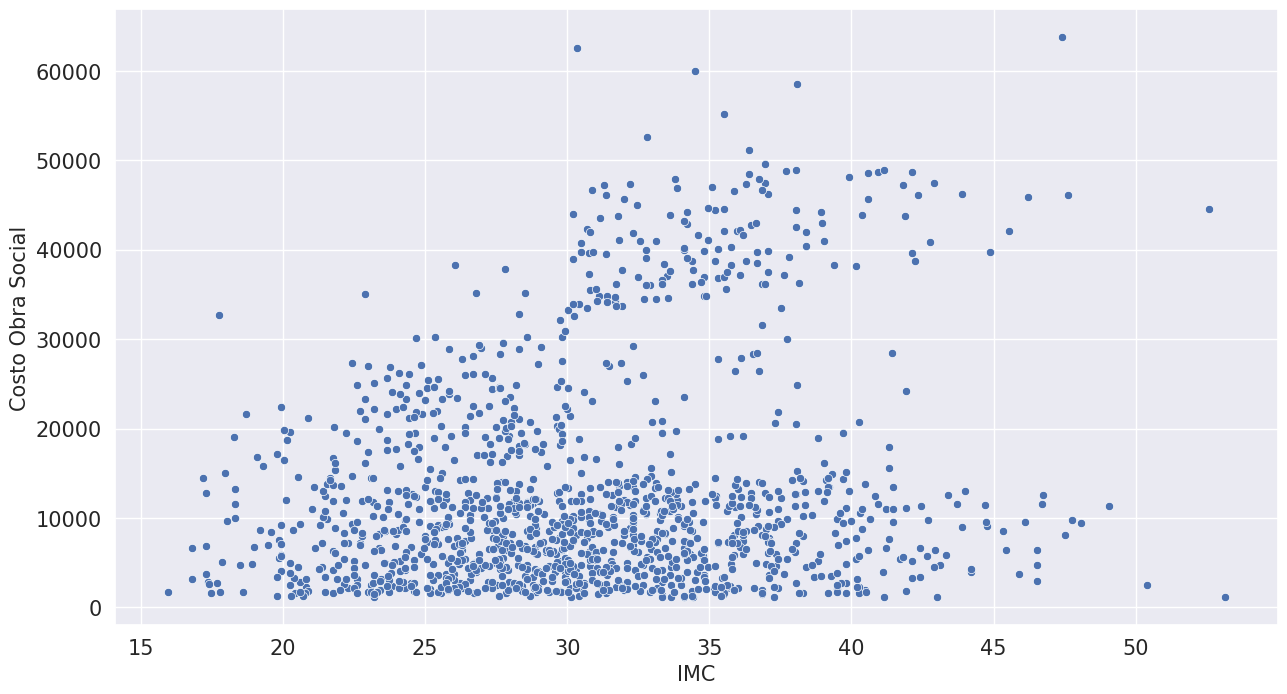

In [ ]:
plt.figure(figsize=(15,8))
ax = sns.scatterplot(x='imc',y='cargos', data=data)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('IMC',fontsize = 15)
plt.ylabel('Costo Obra Social',fontsize = 15);

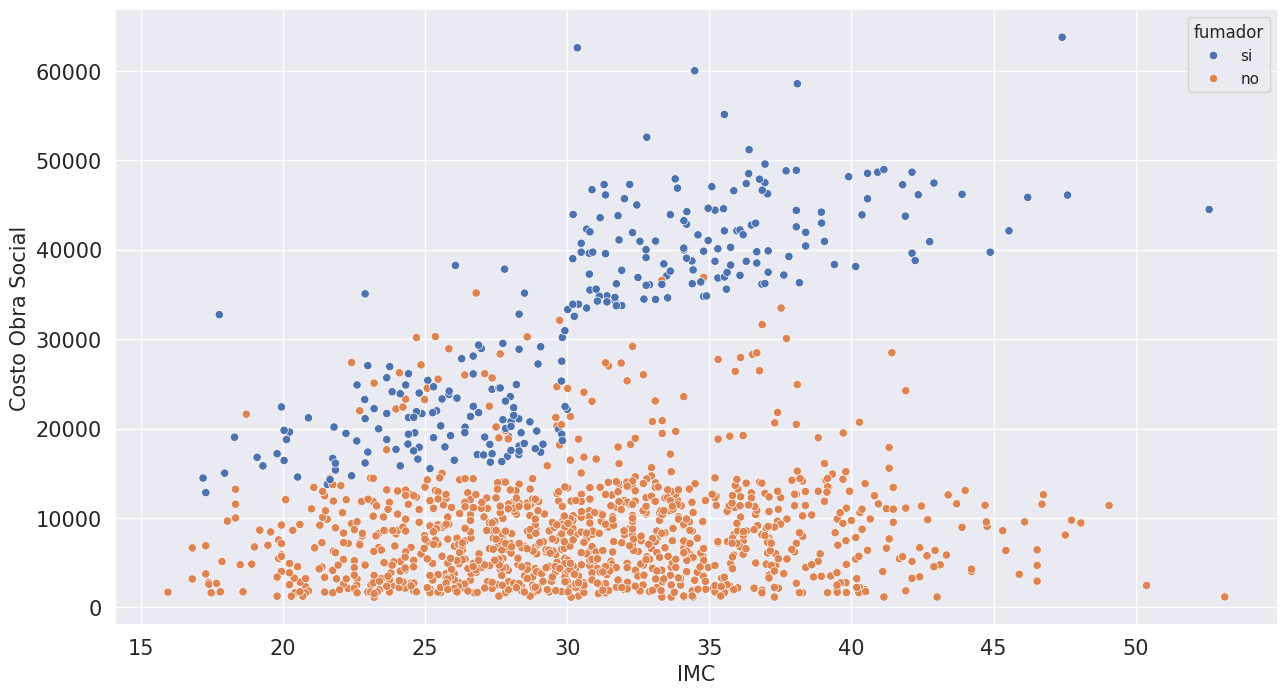

In [ ]:
plt.figure(figsize=(15,8))
ax = sns.scatterplot(x='imc',y='cargos', data=data, hue='fumador')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('IMC',fontsize = 15)
plt.ylabel('Costo Obra Social',fontsize = 15);

## Modelo Fumadores

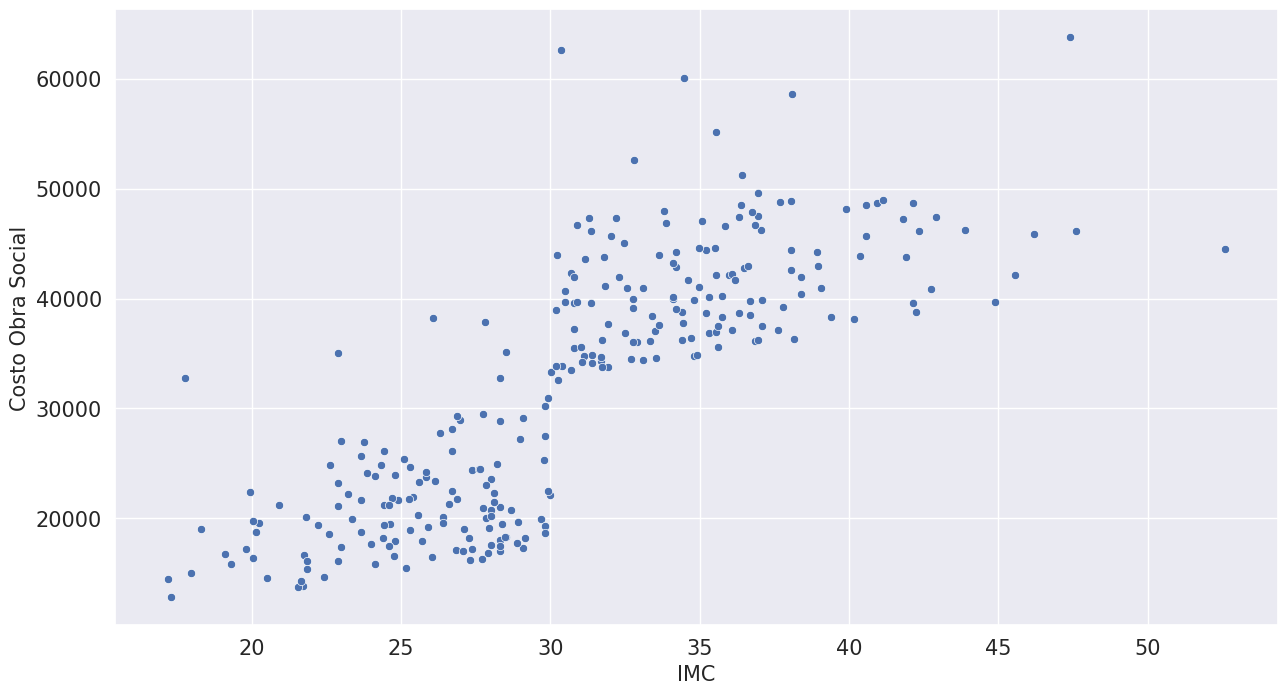

In [ ]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='imc',y='cargos',data=data[data['fumador']=='si'])
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('IMC',fontsize = 15)
plt.ylabel('Costo Obra Social',fontsize = 15);

y = a + bx

costo_obra_social_fum = a + b imc_fum

In [ ]:
fumadores = data[data['fumador']=='si'].copy()
mod_fumadores = smf.ols(formula='cargos ~ imc', data=fumadores)
res_fumadores = mod_fumadores.fit()
print(res_fumadores.summary())

                            OLS Regression Results                            
Dep. Variable:                 cargos   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     506.1
Date:                Sat, 05 Jul 2025   Prob (F-statistic):           5.02e-64
Time:                        14:37:57   Log-Likelihood:                -2807.2
No. Observations:                 274   AIC:                             5618.
Df Residuals:                     272   BIC:                             5626.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.319e+04   2052.885     -6.423      0.0

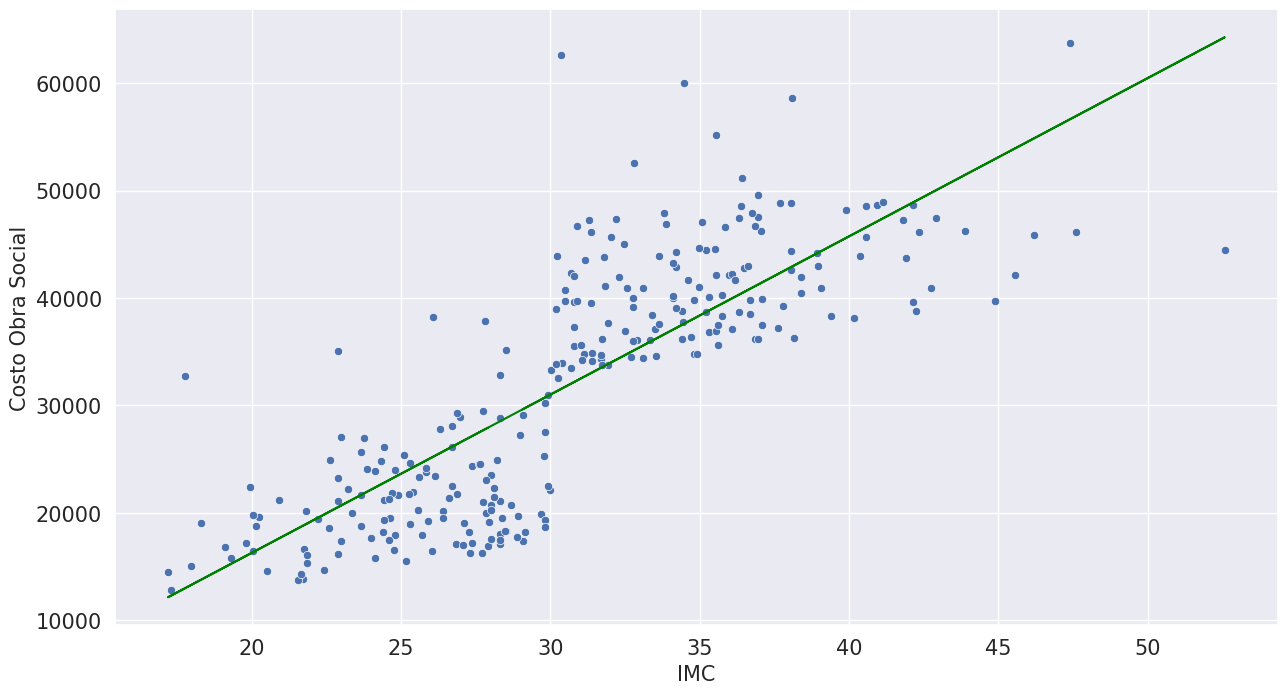

In [ ]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='imc',y='cargos', data = fumadores)
plt.plot(fumadores['imc'], res_fumadores.predict(fumadores['imc']), color = 'green')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('IMC',fontsize = 15)
plt.ylabel('Costo Obra Social',fontsize = 15);

## Modelo para no fumadores

In [ ]:
no_fumadores = data[data['fumador']=='no'].copy()
mod_nofumadores = smf.ols(formula='cargos ~ imc', data=no_fumadores)
res_nofumadores = mod_nofumadores.fit()
print(res_nofumadores.summary())

                            OLS Regression Results                            
Dep. Variable:                 cargos   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     7.553
Date:                Sun, 01 Jun 2025   Prob (F-statistic):            0.00609
Time:                        15:00:35   Log-Likelihood:                -10761.
No. Observations:                1064   AIC:                         2.153e+04
Df Residuals:                    1062   BIC:                         2.154e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   5879.4241    947.475      6.205      0.0

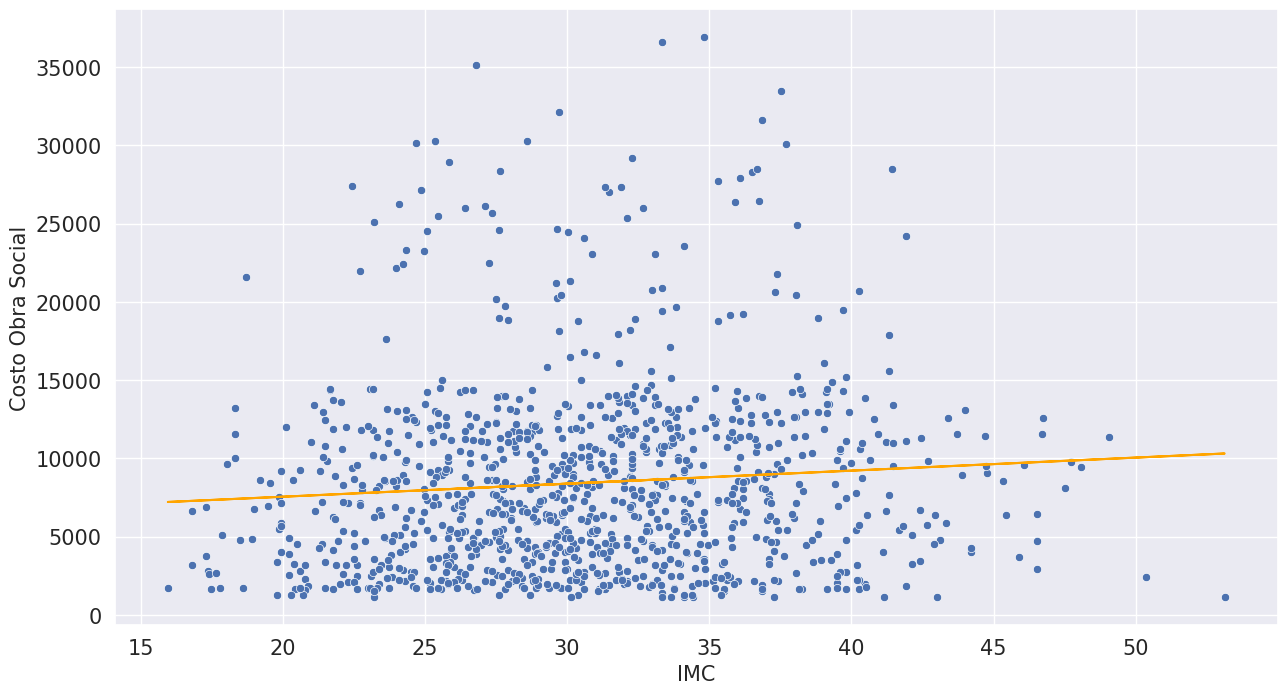

In [ ]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='imc',y='cargos',data =no_fumadores)
plt.plot(no_fumadores['imc'], res_nofumadores.predict(no_fumadores['imc']), color = 'orange')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('IMC',fontsize = 15)
plt.ylabel('Costo Obra Social',fontsize = 15);

# Regresión Lineal Múltiple

## Transformaciones

In [ ]:
original_vars = data.columns
to_dummy = ['sexo', 'fumador', 'region']
dummies = pd.get_dummies(data, columns=to_dummy, drop_first = True, dtype = 'int')
dummies.drop(list(set(original_vars).difference(set(to_dummy))), axis = 1, inplace = True)

data = pd.concat([data, dummies], axis = 1)

In [ ]:
data.region.unique()

array(['suroeste', 'sureste', 'noroeste', 'noreste'], dtype=object)

In [ ]:
data.head()

,edad,sexo,imc,hijos,fumador,region,cargos,sexo_masculino,fumador_si,region_noroeste,region_sureste,region_suroeste
0,19,femenino,27.900,0,si,suroeste,16884.92400,0,1,0,0,1
1,18,masculino,33.770,1,no,sureste,1725.55230,1,0,0,1,0
2,28,masculino,33.000,3,no,sureste,4449.46200,1,0,0,1,0
3,33,masculino,22.705,0,no,noroeste,21984.47061,1,0,1,0,0
4,32,masculino,28.880,0,no,noroeste,3866.85520,1,0,1,0,0


In [ ]:
# data[data['region']=='noreste']

## EDA
En esta parte vamos a explorar las variables que tenemos

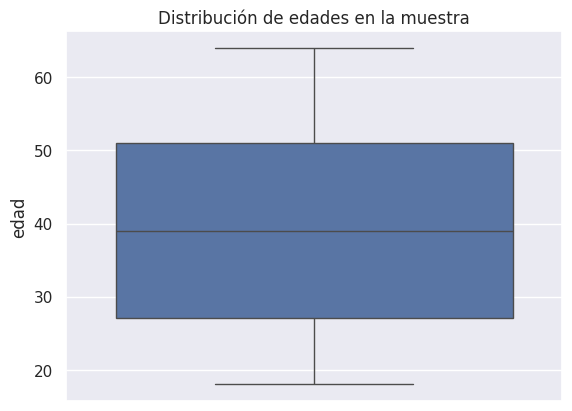

In [ ]:
sns.boxplot(data.edad)
plt.title('Distribución de edades en la muestra');

In [ ]:
data.groupby(['fumador']).size()

fumador
no    1064
si     274
dtype: int64

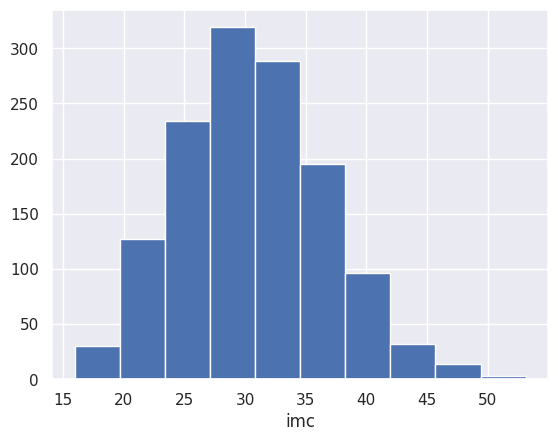

In [ ]:
plt.hist(data['imc'])
plt.xlabel('imc');

<Axes: xlabel='cargos', ylabel='region'>

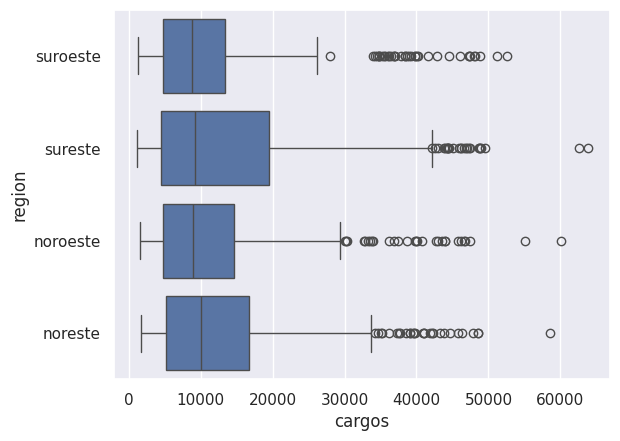

In [ ]:
sns.boxplot(x = 'cargos', y = 'region', data = data)

<Axes: >

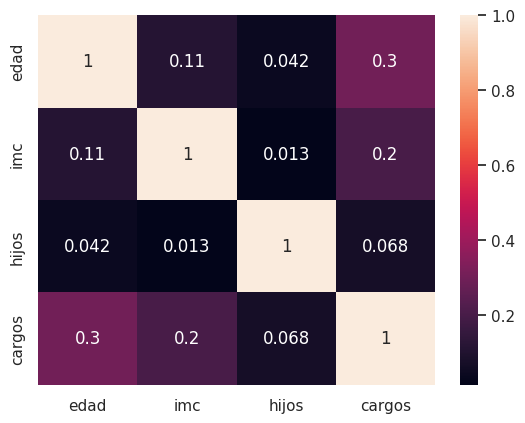

In [ ]:
sns.heatmap(data[['edad', 'imc', 'hijos', 'cargos']].corr(), annot=True)

## Modelo

In [ ]:
data.head()

,edad,sexo,imc,hijos,fumador,region,cargos,sexo_masculino,fumador_si,region_noroeste,region_sureste,region_suroeste
0,19,femenino,27.900,0,si,suroeste,16884.92400,0,1,0,0,1
1,18,masculino,33.770,1,no,sureste,1725.55230,1,0,0,1,0
2,28,masculino,33.000,3,no,sureste,4449.46200,1,0,0,1,0
3,33,masculino,22.705,0,no,noroeste,21984.47061,1,0,1,0,0
4,32,masculino,28.880,0,no,noroeste,3866.85520,1,0,1,0,0


In [ ]:
modelo = smf.ols(formula = 'cargos ~ edad+imc+hijos+sexo_masculino+fumador_si+region_noroeste+region_sureste+region_suroeste', data = data)
res = modelo.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 cargos   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Sat, 05 Jul 2025   Prob (F-statistic):               0.00
Time:                        14:50:39   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -1.194e+04    987.819    -

#### Interpretación de coeficientes
- Cuando aumenta el IMC aumenta el costo del seguro de salud
- Cuando aumenta la edad auenta el costo del seguro de salud
- Si sos mujer el seguro es más barato
- Si sos de Southeast el seguro es más barato

### Limpieza del modelo
En este apartado, vamos alimpiar el modelo para solo utilizar variables estadísticamente significativas

In [ ]:
modelo = smf.ols(formula = 'cargos ~ edad+imc+hijos+fumador_si+region_noroeste+region_sureste+region_suroeste', data = data)
res = modelo.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 cargos   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     572.7
Date:                Sat, 05 Jul 2025   Prob (F-statistic):               0.00
Time:                        14:58:31   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1330   BIC:                         2.715e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -1.199e+04    978.762    -

In [ ]:
modelo = smf.ols(formula = 'cargos ~ edad+imc+hijos+fumador_si+region_sureste+region_suroeste', data = data)
res = modelo.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 cargos   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     668.3
Date:                Sat, 05 Jul 2025   Prob (F-statistic):               0.00
Time:                        14:59:27   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1331   BIC:                         2.715e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -1.217e+04    949.538    -

In [ ]:
modelo = smf.ols(formula = 'cargos ~ edad+imc+hijos+fumador_si', data = data)
res = modelo.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 cargos   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     998.1
Date:                Sat, 05 Jul 2025   Prob (F-statistic):               0.00
Time:                        14:59:57   Log-Likelihood:                -13551.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1333   BIC:                         2.714e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -1.21e+04    941.984    -12.848      0.0